# Tree Cover Loss by Dominant Driver — Yellowstone to Yukon (2001–2022)

This notebook quantifies annual tree cover loss across the Y2Y corridor, disaggregated by the dominant driver of deforestation.

**Datasets:**
- **Hansen Global Forest Change v1.11** — `UMD/hansen/global_forest_change_2023_v1_11`  
  Annual tree cover loss 2001–2023 at 30 m resolution. Key bands: `lossyear`, `treecover2000`.
- **WRI / Google DeepMind Global Drivers of Forest Loss** — `projects/landandcarbon/assets/wri_gdm_drivers_forest_loss_1km/v1_2001_2022`  
  Dominant driver of forest loss per pixel, 2001–2022 at 1 km resolution. Band: `classification`.  
  7 classes: Permanent agriculture, Hard commodities, Shifting cultivation, Logging, Wildfire, Settlements/infrastructure, Other natural disturbances.

**Workflow:**
1. Load datasets and Y2Y boundary
2. Visualize tree cover and loss on an interactive map
3. Calculate annual loss area (ha) per driver
4. Plot time-series of loss by driver
5. Cumulative loss summary
6. Export results to Google Drive

## 1. Load packages and initialize GEE

In [9]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

In [10]:
ee.Authenticate()

True

In [11]:
ee.Initialize(project='y2y-climate-benefits')

## 2. Load datasets

In [12]:
# Hansen Global Forest Change v1.11
hansen     = ee.Image('UMD/hansen/global_forest_change_2023_v1_11')
loss_year  = hansen.select('lossyear')      # 1-23 = 2001-2023; 0 = no loss
tree_cover = hansen.select('treecover2000') # % canopy cover in 2000
loss_mask  = hansen.select('loss')          # 1 = loss in any year

# WRI / Google DeepMind Global Drivers of Forest Loss 2001-2022
# Band 'classification': 1=Permanent ag, 2=Hard commodities, 3=Shifting cultivation,
#                        4=Logging, 5=Wildfire, 6=Settlements/infrastructure, 7=Other natural
drivers = ee.Image('projects/landandcarbon/assets/wri_gdm_drivers_forest_loss_1km/v1_2001_2022') \
            .select('classification').rename('drivers')

# Y2Y boundary
y2y      = ee.FeatureCollection('projects/ee-bermane/assets/y2y')
y2y_geom = y2y.geometry()

START_YEAR = 2001
END_YEAR   = 2022   # drivers layer ends at 2022
MIN_CANOPY = 30     # % canopy cover in 2000 to qualify as forest

print('Hansen bands:',  hansen.bandNames().getInfo())
print('Drivers bands:', drivers.bandNames().getInfo())

Hansen bands: ['treecover2000', 'loss', 'gain', 'lossyear', 'first_b30', 'first_b40', 'first_b50', 'first_b70', 'last_b30', 'last_b40', 'last_b50', 'last_b70', 'datamask']
Drivers bands: ['drivers']


## 3. Driver class definitions

In [13]:
# WRI / Google DeepMind driver classes
DRIVERS = {
    1: ('Permanent agriculture',       '#e63946'),
    2: ('Hard commodities',            '#f4a261'),
    3: ('Shifting cultivation',        '#e9c46a'),
    4: ('Logging',                     '#2a9d8f'),
    5: ('Wildfire',                    '#e76f51'),
    6: ('Settlements/infrastructure',  '#6d6875'),
    7: ('Other natural disturbances',  '#a8dadc'),
}

driver_names  = [v[0] for v in DRIVERS.values()]
driver_colors = [v[1] for v in DRIVERS.values()]

for k, (name, color) in DRIVERS.items():
    print(f'  {k}: {name}  ({color})')

  1: Permanent agriculture  (#e63946)
  2: Hard commodities  (#f4a261)
  3: Shifting cultivation  (#e9c46a)
  4: Logging  (#2a9d8f)
  5: Wildfire  (#e76f51)
  6: Settlements/infrastructure  (#6d6875)
  7: Other natural disturbances  (#a8dadc)


## 4. Visualize tree cover and loss

In [14]:
forest_2000 = tree_cover.gte(MIN_CANOPY)
driver_loss = drivers.updateMask(loss_mask.And(forest_2000))

Map = geemap.Map()
Map.centerObject(y2y_geom, zoom=5)
Map.addLayer(
    tree_cover.clipToCollection(y2y),
    {'min': 0, 'max': 100, 'palette': ['ffffff', '006400']},
    'Tree cover 2000 (%)', True, 0.8
)
Map.addLayer(
    driver_loss.clipToCollection(y2y),
    {'min': 1, 'max': 7, 'palette': driver_colors},
    f'Loss by driver ({START_YEAR}-{END_YEAR})', True, 0.9
)
Map.addLayer(
    y2y.style(**{'color': 'black', 'fillColor': '00000000', 'width': 2}),
    {}, 'Y2Y boundary'
)
Map.add_legend(
    title='Driver of Loss',
    legend_dict={name: color for name, color in zip(driver_names, driver_colors)},
    position='bottomright'
)
Map

Map(center=[55.5658848933782, -121.61243738923375], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Calculate annual loss area (ha) by driver

In [15]:
def compute_loss_by_driver(year):
    year_offset    = year - 2000
    loss_this_year = loss_year.eq(year_offset).And(forest_2000)
    area_img       = ee.Image.pixelArea().rename('area').updateMask(loss_this_year)
    combined       = area_img.addBands(drivers.rename('driver'))
    stats = combined.reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='driver'),
        geometry=y2y_geom,
        scale=30,
        maxPixels=1e13,
        bestEffort=True,
    )
    return stats.get('groups')


print(f'Computing {START_YEAR}-{END_YEAR} at 30 m — takes several minutes...')
rows = []
for yr in range(START_YEAR, END_YEAR + 1):
    groups = compute_loss_by_driver(yr).getInfo()
    for g in groups:
        rows.append({'year': yr, 'driver': int(g['driver']), 'area_m2': g['sum']})
    print(f'  {yr} \u2713')

df = pd.DataFrame(rows)
df['area_ha']     = df['area_m2'] / 1e4
df['area_km2']    = df['area_m2'] / 1e6
df['driver_name'] = df['driver'].map(lambda v: DRIVERS.get(v, (f'Unknown {v}',))[0])

print(f'\nDone. {len(df)} driver-year records.')
print(df.groupby('driver_name')['area_ha'].sum().sort_values(ascending=False).round(0))

Computing 2001-2022 at 30 m — takes several minutes...
  2001 ✓
  2002 ✓
  2003 ✓
  2004 ✓
  2005 ✓
  2006 ✓
  2007 ✓
  2008 ✓
  2009 ✓
  2010 ✓
  2011 ✓
  2012 ✓
  2013 ✓
  2014 ✓
  2015 ✓
  2016 ✓
  2017 ✓
  2018 ✓
  2019 ✓
  2020 ✓
  2021 ✓
  2022 ✓

Done. 132 driver-year records.
driver_name
Wildfire                      5354673.0
Logging                       3350878.0
Other natural disturbances     289621.0
Hard commodities                46961.0
Permanent agriculture           19072.0
Settlements/infrastructure      17844.0
Name: area_ha, dtype: float64


In [16]:
df_pivot = (
    df.pivot_table(index='year', columns='driver_name', values='area_ha', aggfunc='sum')
    .fillna(0)
    .sort_index()
)
for name in driver_names:
    if name not in df_pivot.columns:
        df_pivot[name] = 0
df_pivot = df_pivot[driver_names]

print('Annual loss (ha) by driver:')
print(df_pivot.round(0).to_string())

Annual loss (ha) by driver:
driver_name  Permanent agriculture  Hard commodities  Shifting cultivation   Logging  Wildfire  Settlements/infrastructure  Other natural disturbances
year                                                                                                                                                  
2001                         953.0             837.0                     0  113556.0  196064.0                       613.0                     15695.0
2002                         915.0             755.0                     0  121612.0   87142.0                       663.0                     10745.0
2003                         679.0            1002.0                     0  120552.0  132783.0                       821.0                      5455.0
2004                        1409.0            1571.0                     0  174676.0  478321.0                      1104.0                     56326.0
2005                        1073.0            2068.0              

## 6. Time-series plots

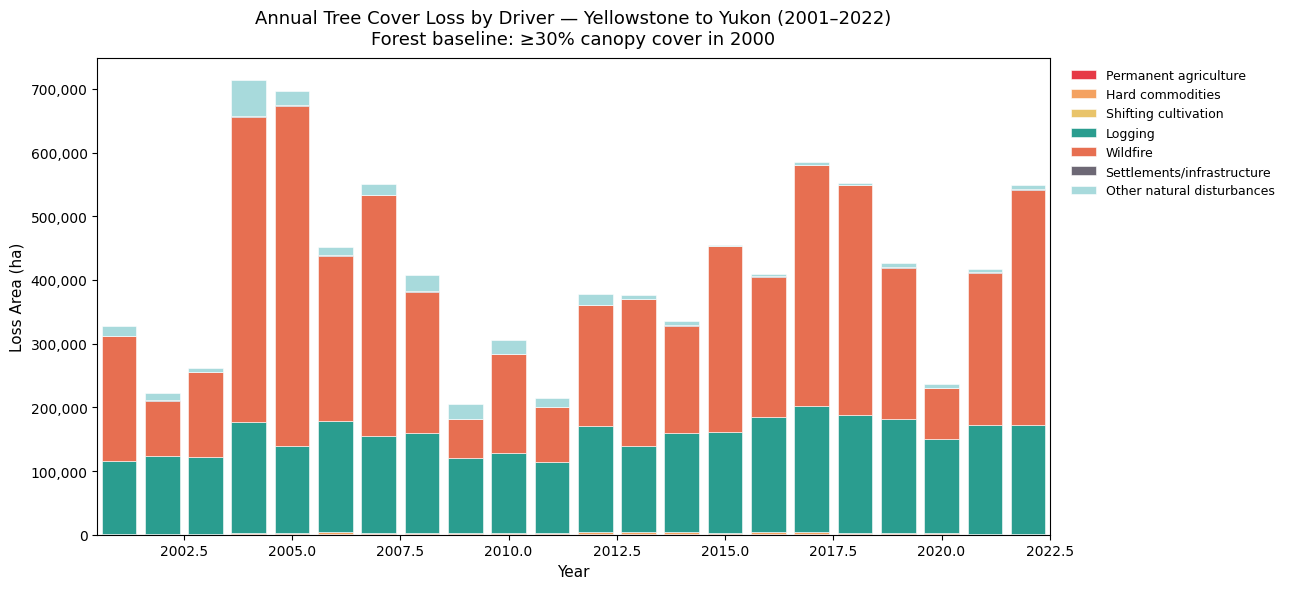

In [17]:
# Stacked bar — annual loss by driver
fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(df_pivot))
for name, color in zip(driver_names, driver_colors):
    vals = df_pivot[name].values
    ax.bar(df_pivot.index, vals, bottom=bottom, label=name,
           color=color, edgecolor='white', linewidth=0.4)
    bottom += vals
ax.set_title(
    f'Annual Tree Cover Loss by Driver — Yellowstone to Yukon ({START_YEAR}\u2013{END_YEAR})\n'
    f'Forest baseline: \u2265{MIN_CANOPY}% canopy cover in 2000',
    fontsize=13, pad=10
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Loss Area (ha)', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('tree_loss_by_driver_annual_y2y.png', dpi=150, bbox_inches='tight')
plt.show()

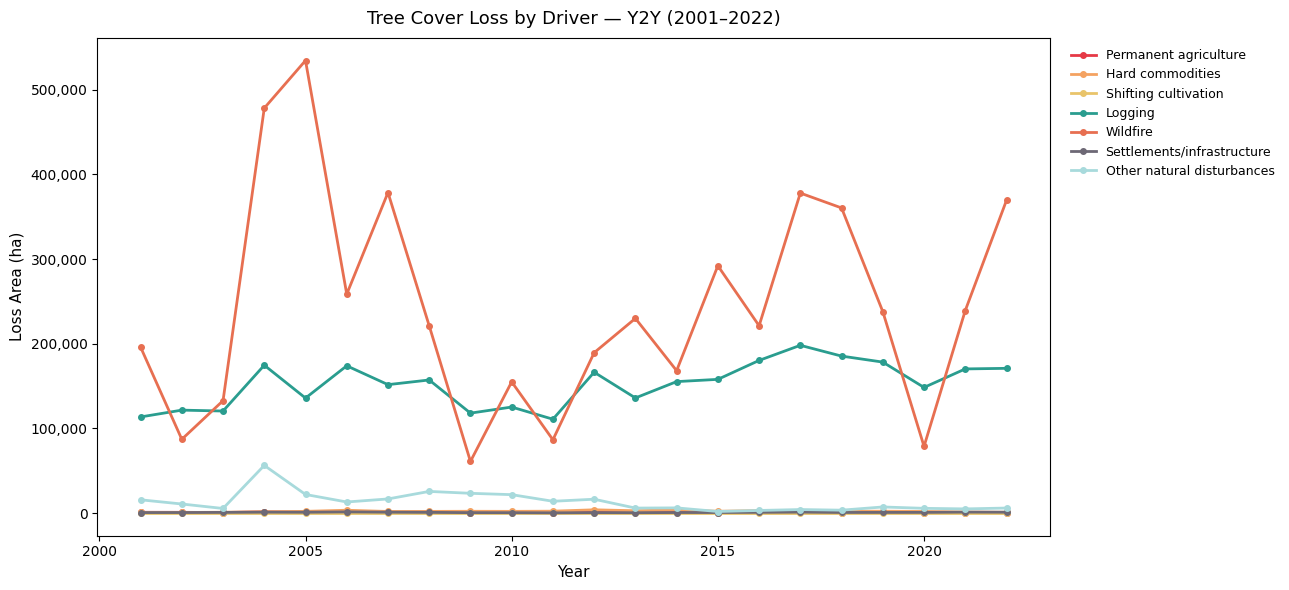

In [18]:
# Line chart — each driver separately
fig, ax = plt.subplots(figsize=(13, 6))
for name, color in zip(driver_names, driver_colors):
    ax.plot(df_pivot.index, df_pivot[name], 'o-', color=color,
            linewidth=2, markersize=4, label=name)
ax.set_title(f'Tree Cover Loss by Driver — Y2Y ({START_YEAR}\u2013{END_YEAR})', fontsize=13, pad=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Loss Area (ha)', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('tree_loss_by_driver_lines_y2y.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cumulative loss summary

Cumulative tree cover loss 2001–2022 (≥30% canopy baseline):
                            Total loss (ha)  Total loss (km²)  Share (%)
driver_name                                                             
Wildfire                          5354673.4           53546.7       59.0
Logging                           3350878.5           33508.8       36.9
Other natural disturbances         289620.8            2896.2        3.2
Hard commodities                    46960.9             469.6        0.5
Permanent agriculture               19071.7             190.7        0.2
Settlements/infrastructure          17844.3             178.4        0.2
Shifting cultivation                    0.0               0.0        0.0

Grand total: 9,079,050 ha  (90,790.5 km²)


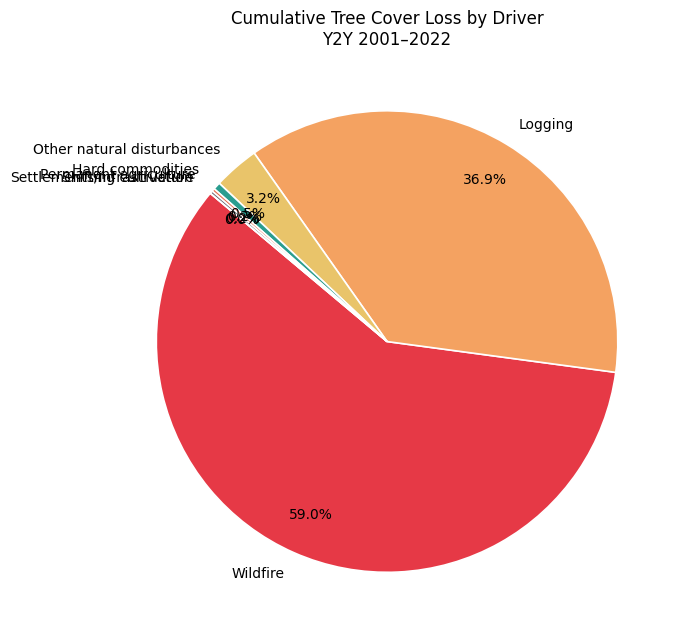

In [19]:
total     = df_pivot.sum().sort_values(ascending=False)
total_all = total.sum()

summary = pd.DataFrame({
    'Total loss (ha)':  total,
    'Total loss (km\u00b2)': (total / 100).round(1),
    'Share (%)':        (total / total_all * 100).round(1),
})
print(f'Cumulative tree cover loss {START_YEAR}\u2013{END_YEAR} (\u2265{MIN_CANOPY}% canopy baseline):')
print(summary.round(1).to_string())
print(f'\nGrand total: {total_all:,.0f} ha  ({total_all/100:,.1f} km\u00b2)')

fig, ax = plt.subplots(figsize=(7, 7))
pie_colors = [DRIVERS[k][1] for k in DRIVERS if DRIVERS[k][0] in total.index]
ax.pie(total.values, labels=total.index, colors=pie_colors,
       autopct='%1.1f%%', startangle=140, pctdistance=0.82,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
ax.set_title(f'Cumulative Tree Cover Loss by Driver\nY2Y {START_YEAR}\u2013{END_YEAR}', fontsize=12)
plt.tight_layout()
plt.savefig('tree_loss_driver_pie_y2y.png', dpi=150, bbox_inches='tight')
plt.show()

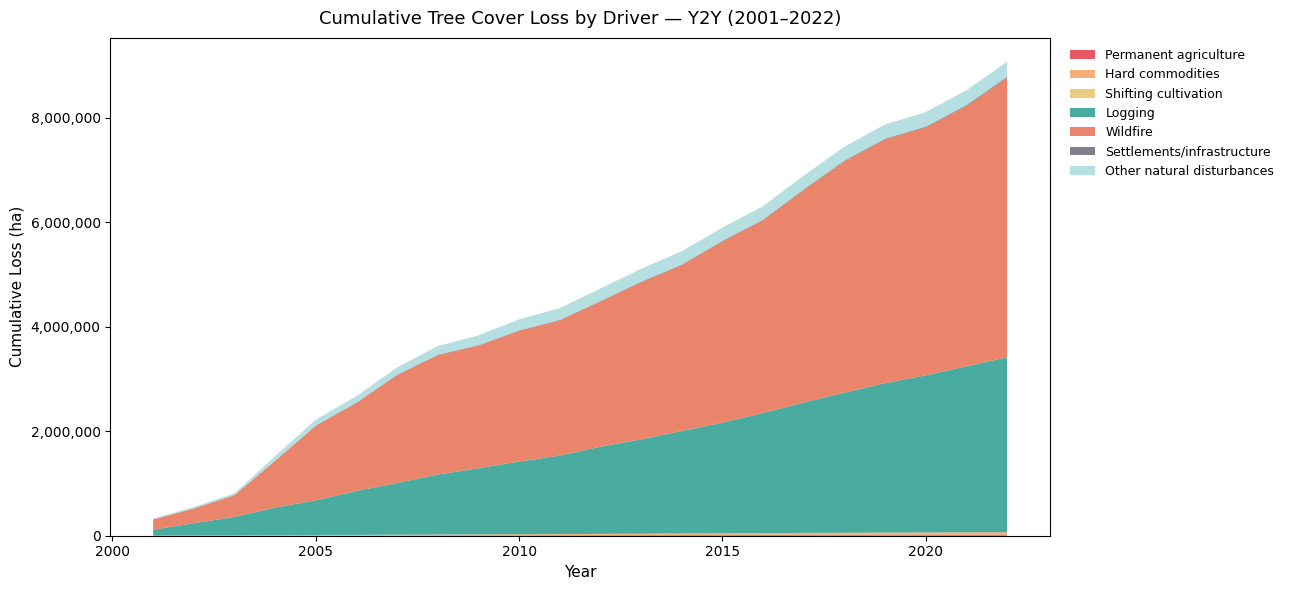

In [20]:
# Cumulative stacked area over time
df_cumul = df_pivot.cumsum()
fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(
    df_cumul.index, [df_cumul[n] for n in driver_names],
    labels=driver_names, colors=driver_colors, alpha=0.85
)
ax.set_title(f'Cumulative Tree Cover Loss by Driver — Y2Y ({START_YEAR}\u2013{END_YEAR})', fontsize=13, pad=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Cumulative Loss (ha)', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('tree_loss_driver_cumulative_y2y.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export results to Google Drive

In [21]:
df_pivot.to_csv(f'tree_loss_by_driver_annual_y2y_{START_YEAR}_{END_YEAR}.csv')
df_cumul.to_csv(f'tree_loss_by_driver_cumulative_y2y_{START_YEAR}_{END_YEAR}.csv')
summary.to_csv(f'tree_loss_driver_summary_y2y_{START_YEAR}_{END_YEAR}.csv')
print('CSVs saved.')

CSVs saved.


In [22]:
DRIVE_FOLDER = 'y2y_tree_loss'
exports = [
    (tree_cover.clipToCollection(y2y).toByte(),
     'y2y_tree_cover_2000'),
    (driver_loss.clipToCollection(y2y).toByte(),
     f'y2y_tree_loss_driver_{START_YEAR}_{END_YEAR}'),
    (loss_year.updateMask(forest_2000).clipToCollection(y2y).toByte(),
     f'y2y_loss_year_{START_YEAR}_{END_YEAR}'),
]
tasks = []
for img, name in exports:
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=name,
        region=y2y_geom,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e13,
    )
    task.start()
    tasks.append(task)
    print(f'Submitted: {name}  \u2192  {task.status()["state"]}')

Submitted: y2y_tree_cover_2000  →  READY
Submitted: y2y_tree_loss_driver_2001_2022  →  READY
Submitted: y2y_loss_year_2001_2022  →  READY


In [23]:
for task in tasks:
    s = task.status()
    print(f'{s["description"]:60s}  {s["state"]}')

y2y_tree_cover_2000                                           READY
y2y_tree_loss_driver_2001_2022                                READY
y2y_loss_year_2001_2022                                       READY
